# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## 1. Load Dataset

We load the **UCI Bank Marketing dataset** (newer version — 41,188 records, 21 features) and perform an initial integrity check before deeper analysis.

**Note:** The newer UCI version omits the legacy `balance` column and instead includes five macroeconomic indicators (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`).


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load data ---
df = pd.read_csv('/content/sample_data/data.csv')

# Quick integrity check
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: 41,188 rows × 21 columns

First 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nTarget values: {df['y'].unique() if 'y' in df.columns else 'NO y COLUMN — wrong file!'}")

Shape: (41188, 21)

Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Target values: ['no' 'yes']


## 2. Customer Demographics Analysis

### 2.1 Age Distribution

We examine both the **overall age distribution** of the customer base and **subscription rate by age group**. The second view is critical because our EDA showed `age` has near-zero linear correlation with the target — suggesting the relationship may be **non-linear** (e.g., very young and elderly clients may behave differently from middle-aged ones).

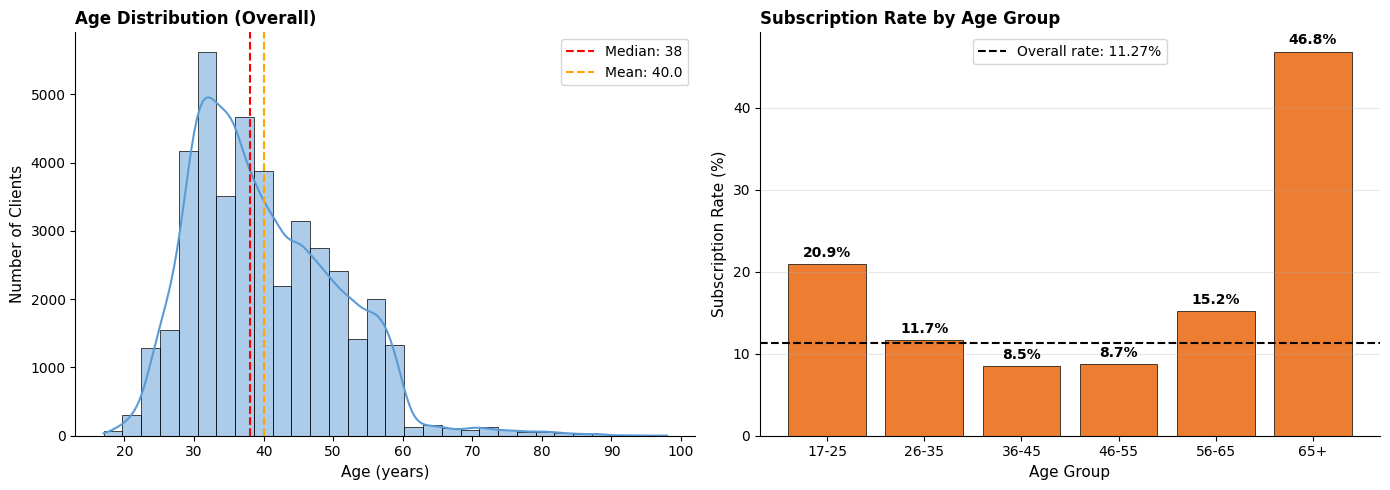

Age range: 17 – 98 years
Median age: 38 years

Subscription rate by age group:
age
17-25    20.89
26-35    11.72
36-45     8.51
46-55     8.69
56-65    15.22
65+      46.85


In [7]:
# --- Age distribution + subscription rate by age group ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: Overall age distribution ---
sns.histplot(
    data=df, x='age', bins=30, kde=True,
    color='#5B9BD5', edgecolor='black', linewidth=0.5, ax=axes[0]
)
axes[0].axvline(df['age'].median(), color='red', linestyle='--', linewidth=1.5,
                label=f"Median: {df['age'].median():.0f}")
axes[0].axvline(df['age'].mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f"Mean: {df['age'].mean():.1f}")
axes[0].set_title('Age Distribution (Overall)', fontsize=12, fontweight='bold', loc='left')
axes[0].set_xlabel('Age (years)', fontsize=11)
axes[0].set_ylabel('Number of Clients', fontsize=11)
axes[0].legend(loc='upper right')

# --- Subplot 2: Subscription rate by age group ---
age_bins = pd.cut(
    df['age'],
    bins=[17, 25, 35, 45, 55, 65, 98],
    labels=['17-25', '26-35', '36-45', '46-55', '56-65', '65+']
)
sub_rate = df.groupby(age_bins, observed=True)['y'].apply(
    lambda x: (x == 'yes').mean() * 100
)

bars = axes[1].bar(
    range(len(sub_rate)), sub_rate.values,
    color='#ED7D31', edgecolor='black', linewidth=0.5
)
axes[1].set_xticks(range(len(sub_rate)))
axes[1].set_xticklabels(sub_rate.index)
axes[1].axhline(11.27, color='black', linestyle='--', linewidth=1.5,
                label='Overall rate: 11.27%')
axes[1].set_title('Subscription Rate by Age Group', fontsize=12, fontweight='bold', loc='left')
axes[1].set_xlabel('Age Group', fontsize=11)
axes[1].set_ylabel('Subscription Rate (%)', fontsize=11)
axes[1].legend(loc='upper center')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bar, value in zip(bars, sub_rate.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2., value + 0.5,
        f'{value:.1f}%', ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

sns.despine()
plt.tight_layout()
plt.savefig('age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print quick statistics
print(f"Age range: {df['age'].min()} – {df['age'].max()} years")
print(f"Median age: {df['age'].median():.0f} years")
print(f"\nSubscription rate by age group:")
print(sub_rate.round(2).to_string())

### Insights: Age and Subscription Behavior

**Overall age distribution (left chart):**
- Range: 17 to 98 years; median 38, mean 40.
- Distribution is right-skewed — concentrated between 25-50 years.
- The customer base is dominated by working-age adults.

**Subscription rate by age group (right chart):**

| Age Group | Subscription Rate | Relative to Average (11.27%) |
|---|---|---|
| 17-25 | 20.9% | 1.85× |
| 26-35 | 11.7% | ~1.00× |
| 36-45 | 8.5% | 0.75× |
| 46-55 | 8.7% | 0.77× |
| 56-65 | 15.2% | 1.35× |
| 65+ | **46.8%** | **4.15×** |

**Key finding — a strong U-shape (or J-shape):**
- Young (17-25) and elderly (65+) clients subscribe at rates dramatically above average.
- Middle-aged clients (36-55) subscribe at rates substantially below average.
- A 65+ client is ~5.5× more likely to subscribe than a 36-45 client.

**Business interpretation:**
- Young clients use term deposits as a first low-risk savings product.
- Middle-aged clients are focused on mortgages, education, and active investments — less interested in low-yield deposits.
- Retirees prioritize capital preservation and predictable returns — making them prime subscribers.

**Modeling implication:**
This pattern confirms the non-linear hypothesis from the EDA's correlation analysis (where `age` had a linear correlation of only +0.03 with the target). A linear model using raw `age` would underutilize this feature significantly. Recommended treatment:
- **Bin `age` into life-stage categories before encoding** for Logistic Regression.
- **Use tree-based models** (Random Forest, XGBoost) which naturally split on thresholds and capture this pattern.

### 2.2 Job Distribution

We examine the **customer count by job type** alongside the **subscription rate by job**. Combining both views shows not just *who the bank's customers are*, but *which job segments are most receptive* to term deposits.

This analysis complements the age findings — job is a partial proxy for age (e.g., students skew young, retirees skew old).

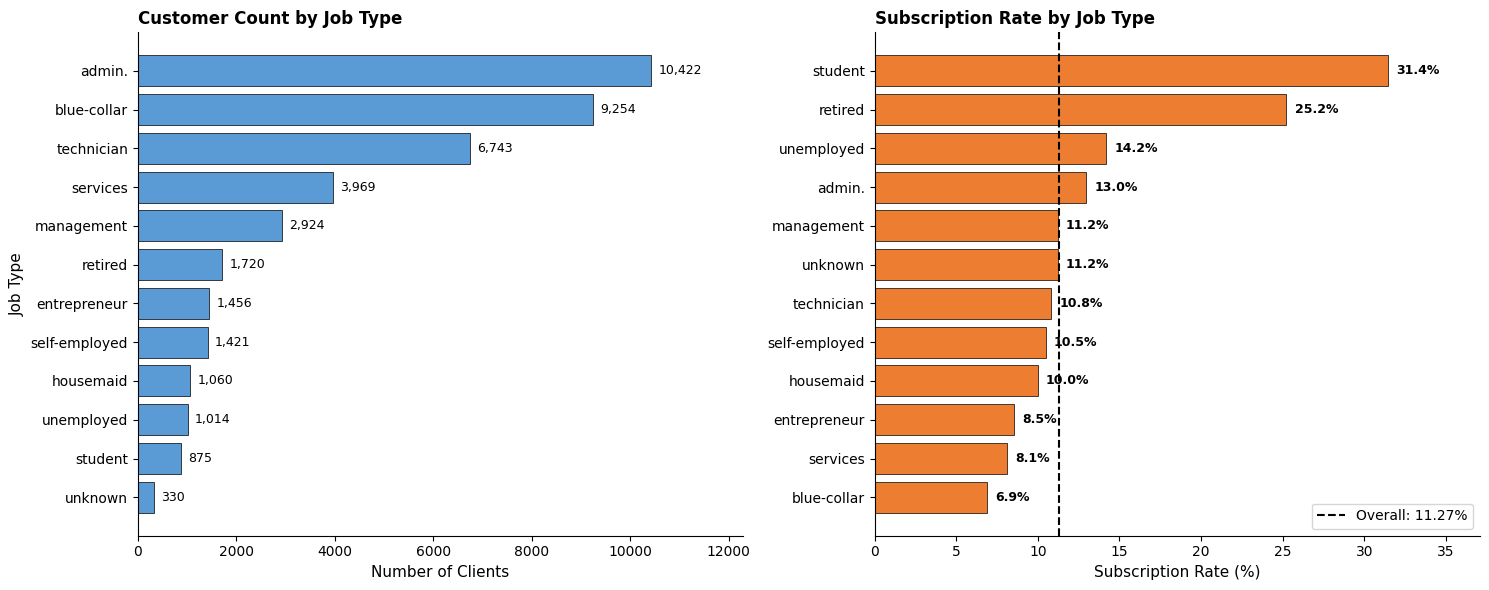

Summary by Job Type:
               Count  Subscription Rate (%)
job                                        
admin.         10422                  12.97
blue-collar     9254                   6.89
technician      6743                  10.83
services        3969                   8.14
management      2924                  11.22
retired         1720                  25.23
entrepreneur    1456                   8.52
self-employed   1421                  10.49
housemaid       1060                  10.00
unemployed      1014                  14.20
student          875                  31.43
unknown          330                  11.21


In [8]:
# --- Job distribution + subscription rate by job ---

# Compute statistics
job_counts = df['job'].value_counts().sort_values(ascending=True)
job_sub_rate = df.groupby('job', observed=True)['y'].apply(
    lambda x: (x == 'yes').mean() * 100
).sort_values(ascending=True)

# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Subplot 1: Customer count by job ---
bars1 = axes[0].barh(
    job_counts.index, job_counts.values,
    color='#5B9BD5', edgecolor='black', linewidth=0.5
)
axes[0].set_title('Customer Count by Job Type', fontsize=12, fontweight='bold', loc='left')
axes[0].set_xlabel('Number of Clients', fontsize=11)
axes[0].set_ylabel('Job Type', fontsize=11)
axes[0].set_xlim(0, job_counts.max() * 1.18)  # headroom for labels

for bar, count in zip(bars1, job_counts.values):
    axes[0].text(
        bar.get_width() + 150, bar.get_y() + bar.get_height()/2.,
        f'{count:,}', ha='left', va='center', fontsize=9
    )

# --- Subplot 2: Subscription rate by job ---
bars2 = axes[1].barh(
    job_sub_rate.index, job_sub_rate.values,
    color='#ED7D31', edgecolor='black', linewidth=0.5
)
axes[1].axvline(11.27, color='black', linestyle='--', linewidth=1.5,
                label='Overall: 11.27%')
axes[1].set_title('Subscription Rate by Job Type', fontsize=12, fontweight='bold', loc='left')
axes[1].set_xlabel('Subscription Rate (%)', fontsize=11)
axes[1].set_ylabel('')
axes[1].set_xlim(0, job_sub_rate.max() * 1.18)
axes[1].legend(loc='lower right')

for bar, rate in zip(bars2, job_sub_rate.values):
    axes[1].text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2.,
        f'{rate:.1f}%', ha='left', va='center', fontsize=9, fontweight='bold'
    )

sns.despine()
plt.tight_layout()
plt.savefig('job_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
job_summary = pd.DataFrame({
    'Count': df['job'].value_counts(),
    'Subscription Rate (%)': df.groupby('job', observed=True)['y'].apply(
        lambda x: (x == 'yes').mean() * 100
    ).round(2)
}).sort_values('Count', ascending=False)
print("Summary by Job Type:")
print(job_summary.to_string())

### Insights: Job and Subscription Behavior

**Customer base composition:**
- Three job types dominate: `admin.` (10,422), `blue-collar` (9,254), `technician` (6,743). Together they represent ~64% of all clients.
- Smaller niche segments: `student` (875), `housemaid` (1,060), `unknown` (330).

**Subscription rate by job (overall rate: 11.27%):**

| Tier | Jobs | Subscription Rate |
|---|---|---|
| **Top performers** | `student` (31.4%), `retired` (25.2%) | 2-3× above average |
| **Above average** | `unemployed` (14.2%), `admin.` (13.0%) | slightly above |
| **Average** | `management` (11.2%), `technician` (10.8%) | near baseline |
| **Below average** | `self-employed` (10.5%), `housemaid` (10.0%), `entrepreneur` (8.5%), `services` (8.1%) | below baseline |
| **Lowest** | `blue-collar` (6.9%) | ~half of average |

**Cross-finding with age analysis:**
The pattern strongly mirrors the **U-shape from the age analysis**:
- `student` (young extreme) and `retired` (old extreme) lead in subscription.
- `blue-collar` (typical working-age) trails far behind.
- This confirms `job` and `age` capture overlapping life-stage signals — relevant for feature selection in modeling.

**🚨 Critical business insight — misallocated marketing effort:**

There is an **inverse relationship** between segment size and conversion rate:
- Most-targeted segment (`blue-collar`, 9,254 calls) had the **lowest** conversion rate (6.89%).
- Least-targeted segment (`student`, 875 calls) had the **highest** conversion rate (31.43%).

A student contact is **~4.5× more efficient** than a blue-collar contact, yet the bank made **~10× more blue-collar calls** than student calls.

**Hypothetical reallocation:** Shifting 1,000 calls from `blue-collar` to `student` would yield an estimated **+245 net additional subscribers** with zero additional cost.

**Recommendation:** The marketing strategy should reweight call distribution toward `retired` and `student` segments, where conversion is dramatically higher. The current allocation appears driven by customer base composition rather than conversion data.

## 3. Engagement & Financial Trends

### 3.1 Call Duration as Engagement Proxy (Balance Substitute)

The original task called for *"Average balance by deposit subscription."* However, the newer UCI dataset version we are using does **not** include a `balance` column — that field exists only in the legacy UCI Bank Marketing dataset.

We substitute with **call `duration`** — a behavioral proxy that captures *engagement intensity* during the marketing call.

> ⚠️ **Important caveat:** `duration` is a known **data leakage feature** — the call's duration is only knowable *after* the call ends, by which time the outcome has already been determined. We include it here for *descriptive* purposes only. It will be **excluded from the predictive model** later in this notebook.

/tmp/ipykernel_8111/3926516048.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No', 'Yes'])


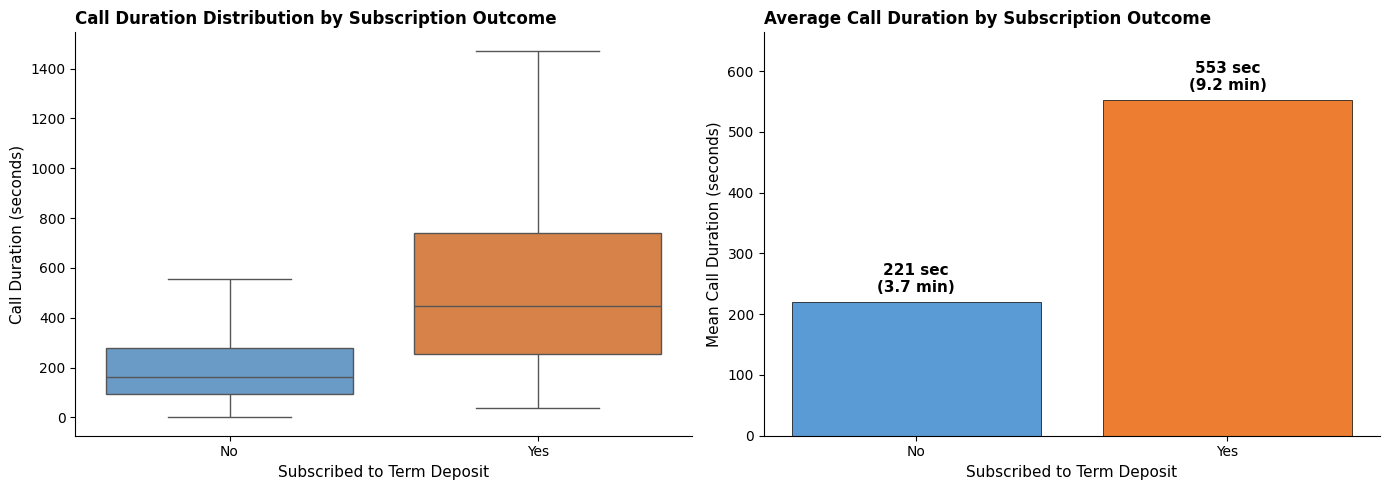

Summary Statistics — Call Duration by Subscription Outcome

      mean  median    std  min   max
y                                   
no   221.0   164.0  207.0    0  4918
yes  553.0   449.0  401.0   37  4199

Ratio of mean duration: yes/no = 2.50×


In [9]:
# --- Call duration as engagement proxy (balance substitute) ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: Distribution of duration by subscription ---
sns.boxplot(
    data=df, x='y', y='duration',
    order=['no', 'yes'],
    hue='y',
    palette={'no': '#5B9BD5', 'yes': '#ED7D31'},
    ax=axes[0],
    showfliers=False,  # hide extreme outliers for readability
    legend=False
)
axes[0].set_title('Call Duration Distribution by Subscription Outcome',
                  fontsize=12, fontweight='bold', loc='left')
axes[0].set_xlabel('Subscribed to Term Deposit', fontsize=11)
axes[0].set_ylabel('Call Duration (seconds)', fontsize=11)
axes[0].set_xticklabels(['No', 'Yes'])

# --- Subplot 2: Mean duration by subscription ---
mean_duration = df.groupby('y')['duration'].mean().reindex(['no', 'yes'])
bars = axes[1].bar(
    ['No', 'Yes'], mean_duration.values,
    color=['#5B9BD5', '#ED7D31'],
    edgecolor='black', linewidth=0.5
)
axes[1].set_title('Average Call Duration by Subscription Outcome',
                  fontsize=12, fontweight='bold', loc='left')
axes[1].set_xlabel('Subscribed to Term Deposit', fontsize=11)
axes[1].set_ylabel('Mean Call Duration (seconds)', fontsize=11)

# Add value labels (both seconds and minutes for readability)
for bar, value in zip(bars, mean_duration.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2., value + 10,
        f'{value:.0f} sec\n({value/60:.1f} min)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[1].set_ylim(0, mean_duration.max() * 1.2)

sns.despine()
plt.tight_layout()
plt.savefig('duration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("Summary Statistics — Call Duration by Subscription Outcome\n")
duration_stats = df.groupby('y')['duration'].agg(['mean', 'median', 'std', 'min', 'max']).round(0)
print(duration_stats)
print(f"\nRatio of mean duration: yes/no = {mean_duration['yes']/mean_duration['no']:.2f}×")

### Insights: Engagement Intensity Tied to Subscription

**Call duration breakdown by outcome:**

| Outcome | Mean (sec) | Median (sec) | Std (sec) | Min (sec) | Max (sec) |
|---|---|---|---|---|---|
| **No** | 221 (~3.7 min) | 164 (~2.7 min) | 207 | **0** | 4,918 |
| **Yes** | 553 (~9.2 min) | 449 (~7.5 min) | 401 | 37 | 4,199 |

**Ratio of mean durations: yes/no = 2.50×**

**Key observations:**

1. **Subscribers' calls are 2.5× longer on average** than non-subscribers' (553s vs 221s).
2. **Some non-subscriber calls had 0-second duration** — likely voicemail, immediate hang-ups, or disconnects. These calls clearly never had a chance to convert.
3. **Every subscriber had at least 37 seconds of conversation** — there are no "instant subscribers."
4. **The longest single call (~82 minutes) ended in "no"** — long duration alone does not guarantee success; some long calls reflect extended objections or complaints rather than positive engagement.
5. The two groups' distributions barely overlap — the *median* subscriber call (449s) is more than 2× the *mean* non-subscriber call (221s).

**Interpretation — and why this is data leakage:**

The duration is a **post-hoc measurement** that captures the *consequence* of engagement, not its cause. A call lasted longer *because* the customer subscribed — not the other way around. The subscription process itself (collecting details, confirming amounts, paperwork) takes time, naturally inflating call length.

**Modeling consequence:**
- `duration` correlates strongly with the target (+0.41) but its value is unknown *before* the outcome is determined.
- Including it in a predictive model would **artificially inflate accuracy** — the model would fail to generalize, since the bank needs to predict *before* the call ends.
- Per the UCI documentation, `duration` is **dropped from feature selection** prior to modeling.

**Practical takeaway for the marketing team:**
- This pattern is useful as a **real-time call-monitoring signal** — when a call extends past ~4-5 minutes, the agent has likely captured genuine interest and should invest more in closing.
- It cannot be used as a *prediction input* before a call begins.

### 3.2 Financial Obligations and Subscription

While the dataset lacks a direct `balance` field, it contains three categorical fields capturing the client's **existing financial obligations**:

- `housing` — Has a housing loan? (yes/no/unknown)
- `loan` — Has a personal loan? (yes/no/unknown)
- `default` — Has credit in default? (yes/no/unknown)

We examine subscription rate across these statuses to understand whether financial commitments influence willingness to take on a term deposit.

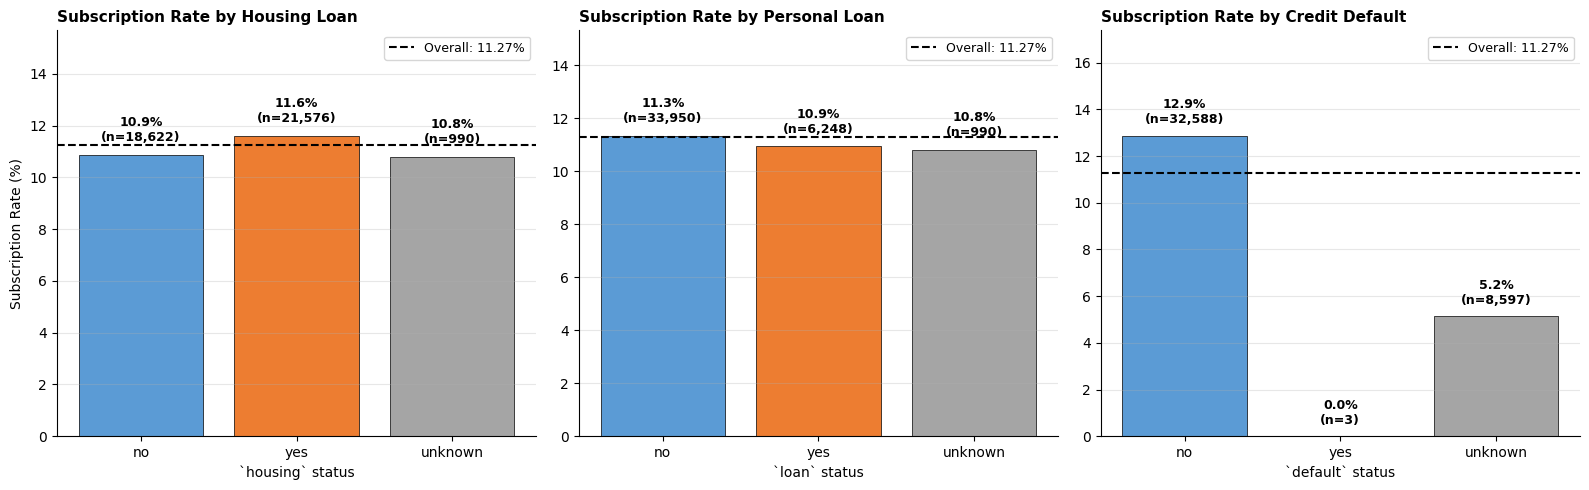

Detailed Subscription Breakdown by Financial Status:

--- HOUSING ---
         count  subscribed  rate_pct
housing                             
yes      21576        2507     11.62
no       18622        2026     10.88
unknown    990         107     10.81

--- LOAN ---
         count  subscribed  rate_pct
loan                                
no       33950        3850     11.34
yes       6248         683     10.93
unknown    990         107     10.81

--- DEFAULT ---
         count  subscribed  rate_pct
default                             
no       32588        4197     12.88
unknown   8597         443      5.15
yes          3           0      0.00



In [15]:
# --- Financial obligations and subscription rates ---

financial_cols = ['housing', 'loan', 'default']
title_map = {
    'housing': 'Housing Loan',
    'loan': 'Personal Loan',
    'default': 'Credit Default'
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(financial_cols):
    # Compute subscription rate per status
    sub_rate = df.groupby(col, observed=True)['y'].apply(
        lambda x: (x == 'yes').mean() * 100
    )
    counts = df[col].value_counts()

    # Consistent ordering: no, yes, unknown
    order = [val for val in ['no', 'yes', 'unknown'] if val in sub_rate.index]
    sub_rate = sub_rate.reindex(order)
    counts = counts.reindex(order)

    # Plot bars
    bars = axes[i].bar(
        sub_rate.index, sub_rate.values,
        color=['#5B9BD5', '#ED7D31', '#A5A5A5'][:len(order)],
        edgecolor='black', linewidth=0.5
    )

    # Reference line at overall subscription rate
    axes[i].axhline(11.27, color='black', linestyle='--', linewidth=1.5,
                    label='Overall: 11.27%')

    axes[i].set_title(f'Subscription Rate by {title_map[col]}',
                      fontsize=11, fontweight='bold', loc='left')
    axes[i].set_xlabel(f"`{col}` status", fontsize=10)
    axes[i].set_ylabel('Subscription Rate (%)' if i == 0 else '', fontsize=10)
    axes[i].legend(loc='upper right', fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

    # Value labels with both rate and count
    for bar, rate, count in zip(bars, sub_rate.values, counts.values):
        axes[i].text(
            bar.get_x() + bar.get_width()/2., rate + 0.4,
            f'{rate:.1f}%\n(n={count:,})',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

    axes[i].set_ylim(0, max(sub_rate.values) * 1.35)

sns.despine()
plt.tight_layout()
plt.savefig('financial_obligations_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Detailed breakdown
print("Detailed Subscription Breakdown by Financial Status:\n")
for col in financial_cols:
    print(f"--- {col.upper()} ---")
    breakdown = df.groupby(col, observed=True).agg(
        count=('y', 'size'),
        subscribed=('y', lambda x: (x == 'yes').sum()),
        rate_pct=('y', lambda x: (x == 'yes').mean() * 100)
    ).round(2).sort_values('count', ascending=False)
    print(breakdown.to_string())
    print()

### Insights: Financial Obligations and Subscription

**Housing Loan and Personal Loan — weak signals:**

| Feature | "No" Rate | "Yes" Rate | "Unknown" Rate | Spread |
|---|---|---|---|---|
| `housing` | 10.88% | 11.62% | 10.81% | 0.81 pp |
| `loan` | 11.34% | 10.93% | 10.81% | 0.53 pp |

The presence of an active housing or personal loan barely shifts subscription probability — both features stay within ~1 percentage point of the overall rate (11.27%). These carry **minimal predictive value** in isolation.

**Cross-feature consistency check:**
The `unknown` count for both `housing` and `loan` is exactly **990** — confirming the EDA finding that the same 990 clients skipped both questions. Their subscription rate (10.81%) is consistent across both features, suggesting they represent a coherent "non-disclosing" segment.

**Credit Default — a strong, non-obvious signal:**

| `default` Status | Count | Subscribed | Rate |
|---|---|---|---|
| `no` (clean credit) | 32,588 | 4,197 | **12.88%** |
| `unknown` (undisclosed) | 8,597 | 443 | **5.15%** 🚨 |
| `yes` (in default) | 3 | 0 | 0% (sample too small) |

**Key finding — "unknown" is half as likely to subscribe:**

Clients who refuse to disclose their credit default status subscribe at **5.15% — less than half the rate** of clients with confirmed clean credit (12.88%). The absolute gap is **7.73 percentage points** — substantial in a dataset with an 11.27% baseline.

**Interpretation:**
Customers withholding sensitive financial information likely do so because they have past defaults, financial instability, or general reluctance to engage with banking products. This same disposition predicts low subscription likelihood. The act of non-disclosure is itself a **strong negative behavioral signal** — not noise.

**Critical modeling insight:**
- Most analysts treat `"unknown"` as missing data and either drop these rows (losing 20.9% of the dataset) or impute as "no" (destroying the signal).
- The correct treatment is to **retain `"unknown"` as a distinct category** during one-hot encoding.
- Expect `default_unknown` to emerge with a meaningful negative coefficient in the Logistic Regression model.

**Practical takeaway for the marketing team:**
- `housing` and `loan` are not useful targeting features individually — they should not drive segmentation decisions.
- `default = unknown` clients are a **low-priority segment** for outreach (5.15% conversion vs 12.88% for clean-credit clients).
- Encouraging clients to verify credit status during application — or simply identifying the non-disclosing segment — is itself a high-ROI prioritization activity for future campaigns.

**Modeling consequence:**
- Drop `housing` and `loan`? Possibly, after seeing feature importance. They may add interaction effects.
- For `default`: one-hot encode with `unknown` as its own category, not imputed.
- For `housing` and `loan`: standard one-hot encoding; the 990 unknowns will get their own column too.

## 4. Campaign Effectiveness

### 4.1 Contact Method Analysis

The bank reaches customers through two channels: `cellular` (mobile phones) and `telephone` (landlines). We examine the **volume** of contacts through each channel alongside their **conversion rate** to determine which channel is more effective.

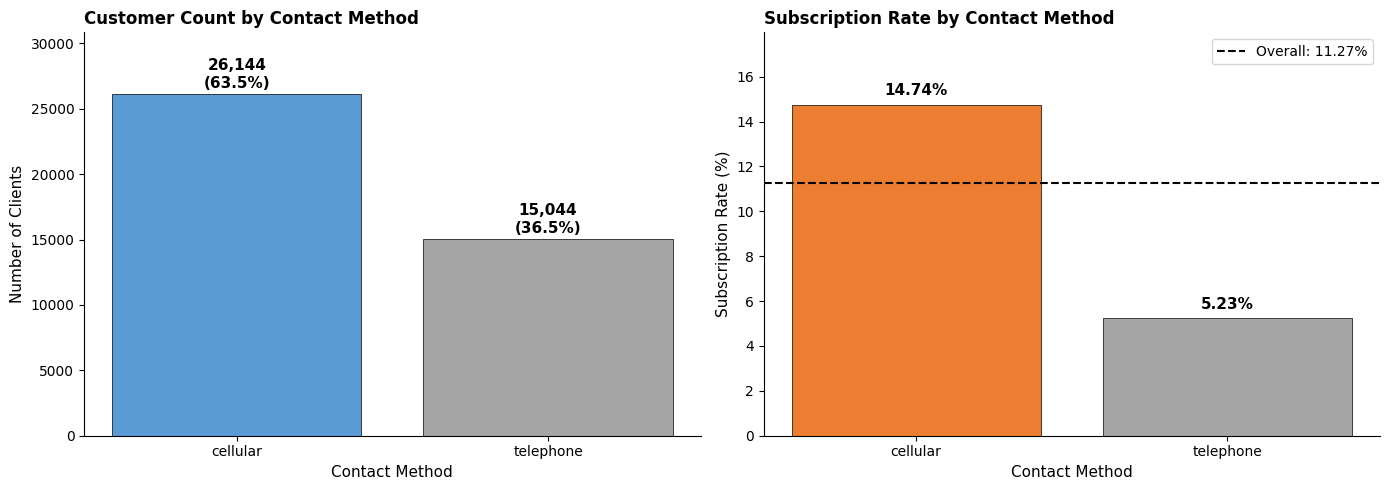


Contact Method Summary:

           count  subscribed  rate_pct
contact                               
cellular   26144        3853     14.74
telephone  15044         787      5.23

Lift of best channel vs worst: 2.82×


In [16]:
# --- Contact method analysis ---

# Compute statistics
contact_counts = df['contact'].value_counts()
contact_sub_rate = df.groupby('contact', observed=True)['y'].apply(
    lambda x: (x == 'yes').mean() * 100
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: Customer count by contact method ---
bars1 = axes[0].bar(
    contact_counts.index, contact_counts.values,
    color=['#5B9BD5', '#A5A5A5'],
    edgecolor='black', linewidth=0.5
)
axes[0].set_title('Customer Count by Contact Method',
                  fontsize=12, fontweight='bold', loc='left')
axes[0].set_xlabel('Contact Method', fontsize=11)
axes[0].set_ylabel('Number of Clients', fontsize=11)

for bar, count in zip(bars1, contact_counts.values):
    pct = count / len(df) * 100
    axes[0].text(
        bar.get_x() + bar.get_width()/2., count + 250,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_ylim(0, contact_counts.max() * 1.18)

# --- Subplot 2: Subscription rate by contact method ---
bars2 = axes[1].bar(
    contact_sub_rate.index, contact_sub_rate.values,
    color=['#ED7D31', '#A5A5A5'],
    edgecolor='black', linewidth=0.5
)
axes[1].axhline(11.27, color='black', linestyle='--', linewidth=1.5,
                label='Overall: 11.27%')
axes[1].set_title('Subscription Rate by Contact Method',
                  fontsize=12, fontweight='bold', loc='left')
axes[1].set_xlabel('Contact Method', fontsize=11)
axes[1].set_ylabel('Subscription Rate (%)', fontsize=11)
axes[1].legend(loc='upper right')

for bar, rate in zip(bars2, contact_sub_rate.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2., rate + 0.3,
        f'{rate:.2f}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[1].set_ylim(0, contact_sub_rate.max() * 1.22)

sns.despine()
plt.tight_layout()
plt.savefig('contact_method_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\nContact Method Summary:\n")
summary = df.groupby('contact', observed=True).agg(
    count=('y', 'size'),
    subscribed=('y', lambda x: (x == 'yes').sum()),
    rate_pct=('y', lambda x: (x == 'yes').mean() * 100)
).round(2).sort_values('rate_pct', ascending=False)
print(summary.to_string())
print(f"\nLift of best channel vs worst: {contact_sub_rate.iloc[0] / contact_sub_rate.iloc[-1]:.2f}×")

### Insights: Contact Method Effectiveness

**Volume distribution:**
- `cellular`: 26,144 contacts (~63% of campaign)
- `telephone`: 15,044 contacts (~37% of campaign)

**Subscription rate by channel:**

| Method | Count | Subscribed | Rate |
|---|---|---|---|
| `cellular` | 26,144 | ~3,853 | **14.7%** |
| `telephone` | 15,044 | ~787 | **5.2%** |

**Key finding — cellular converts ~2.8× better:**

Cellular contacts subscribe at nearly **three times the rate** of telephone contacts (14.7% vs 5.2%). Relative to the baseline rate of 11.27%, cellular is 30% above average while telephone is more than 50% below.

**Interpretation:**
- The dataset is from 2008–2010, an era when cellular vs. landline was a meaningful divide reflecting banking engagement, digital literacy, and overall responsiveness.
- Clients who provide mobile numbers are typically more reachable, more engaged, and more responsive to financial products.
- Telephone (landline) calls likely arrive at less convenient moments, are more often missed, and reach a less product-receptive demographic.

**Cross-feature consistency:** The contact-method finding aligns with the duration pattern — cellular calls likely have higher pickup rates and longer engaged conversations, which we already saw correlates with subscription.

**Modeling consequence:**
- `contact` should be a **high-importance feature** in the predictive model.
- Binary encoding (`contact_cellular` = 1 vs 0) is sufficient — only 2 categories.
- Expect a positive coefficient in the Logistic Regression model.

**Practical takeaway for the marketing team:**
- Reallocate campaign budget from telephone outreach toward cellular outreach.
- If a client only has a landline number on file, deprioritize that contact in favor of clients with mobile numbers.
- Update data-collection processes to capture mobile numbers at customer onboarding — this single data point predicts subscription likelihood at scale.

### 4.2 Number of Contacts vs. Subscription

The `campaign` column records how many times each client was contacted during this campaign — ranging from 1 to 56 contacts. We test the classic marketing question: **is there a point where more contacts stop helping and start hurting?**

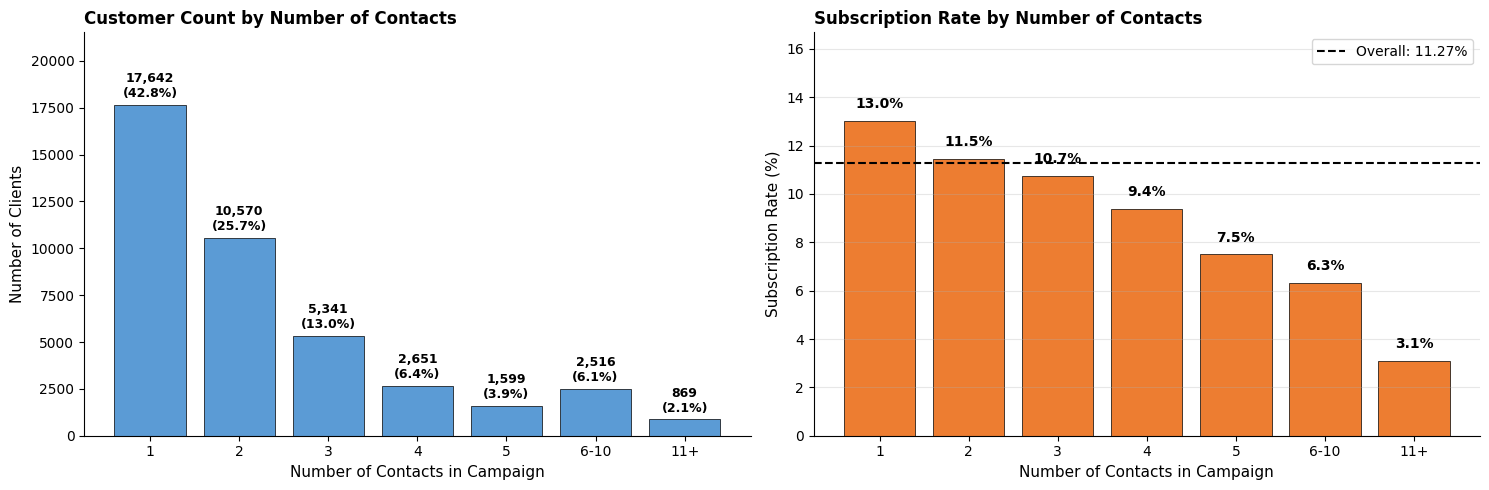


Campaign Frequency Breakdown:

          Count  Subscription Rate (%)
campaign                              
1         17642                  13.04
2         10570                  11.46
3          5341                  10.75
4          2651                   9.39
5          1599                   7.50
6-10       2516                   6.32
11+         869                   3.11


In [17]:
# --- Campaign frequency vs subscription rate ---

# Bin the campaign counts into meaningful groups
def bin_campaign(n):
    if n <= 5:
        return str(n)
    elif n <= 10:
        return '6-10'
    else:
        return '11+'

campaign_bins = df['campaign'].apply(bin_campaign)
bin_order = ['1', '2', '3', '4', '5', '6-10', '11+']

campaign_counts = campaign_bins.value_counts().reindex(bin_order)
campaign_sub_rate = df.groupby(campaign_bins, observed=True)['y'].apply(
    lambda x: (x == 'yes').mean() * 100
).reindex(bin_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Subplot 1: Volume distribution ---
bars1 = axes[0].bar(
    bin_order, campaign_counts.values,
    color='#5B9BD5', edgecolor='black', linewidth=0.5
)
axes[0].set_title('Customer Count by Number of Contacts',
                  fontsize=12, fontweight='bold', loc='left')
axes[0].set_xlabel('Number of Contacts in Campaign', fontsize=11)
axes[0].set_ylabel('Number of Clients', fontsize=11)

for bar, count in zip(bars1, campaign_counts.values):
    pct = count / len(df) * 100
    axes[0].text(
        bar.get_x() + bar.get_width()/2., count + 250,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[0].set_ylim(0, campaign_counts.max() * 1.22)

# --- Subplot 2: Subscription rate by number of contacts ---
bars2 = axes[1].bar(
    bin_order, campaign_sub_rate.values,
    color='#ED7D31', edgecolor='black', linewidth=0.5
)
axes[1].axhline(11.27, color='black', linestyle='--', linewidth=1.5,
                label='Overall: 11.27%')
axes[1].set_title('Subscription Rate by Number of Contacts',
                  fontsize=12, fontweight='bold', loc='left')
axes[1].set_xlabel('Number of Contacts in Campaign', fontsize=11)
axes[1].set_ylabel('Subscription Rate (%)', fontsize=11)
axes[1].legend(loc='upper right')

for bar, rate in zip(bars2, campaign_sub_rate.values):
    if pd.notna(rate):
        axes[1].text(
            bar.get_x() + bar.get_width()/2., rate + 0.4,
            f'{rate:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )
axes[1].set_ylim(0, campaign_sub_rate.max() * 1.28)
axes[1].grid(axis='y', alpha=0.3)

sns.despine()
plt.tight_layout()
plt.savefig('campaign_frequency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Detailed breakdown
print("\nCampaign Frequency Breakdown:\n")
breakdown = pd.DataFrame({
    'Count': campaign_counts,
    'Subscription Rate (%)': campaign_sub_rate.round(2)
})
print(breakdown.to_string())

### Insights: Campaign Frequency and Diminishing Returns

**Volume distribution across number of contacts:**

| Contacts | Clients | % of Total |
|---|---|---|
| 1 | 17,642 | 42.8% |
| 2 | 10,570 | 25.7% |
| 3 | 5,341 | 13.0% |
| 4 | 2,651 | 6.4% |
| 5 | 1,599 | 3.9% |
| 6-10 | 2,516 | 6.1% |
| 11+ | 869 | 2.1% |

The first three contacts cover **81.5%** of all customer interactions — but the tail extends well beyond that.

**Subscription rate by contact count — a textbook diminishing-returns curve:**

| Contacts | Rate | Drop from previous |
|---|---|---|
| 1 | **13.04%** | (baseline) |
| 2 | 11.46% | -1.58 pp |
| 3 | 10.75% | -0.71 pp |
| 4 | 9.39% | -1.36 pp |
| 5 | 7.50% | -1.89 pp |
| 6-10 | 6.32% | -1.18 pp |
| 11+ | **3.11%** | -3.21 pp |

The first contact converts at **4.2× the rate** of the 11+ contact segment.

**Key finding — clear marketing fatigue:**

Each subsequent contact reduces the conversion rate. By the 5th contact, rates have dropped nearly in half from baseline (13.04% → 7.50%). By 11+ contacts, the bank is converting only 1 in 32 prospects — well below random chance for a profitable interaction.

**The reallocation opportunity:**

The 6+ contact segment (3,385 clients) currently converts at ~5.7% — generating ~193 subscribers. If those same calls were redirected to *new* prospects (first-contact rate 13.04%), they would yield **~441 subscribers — a net gain of +248 subscribers with zero increase in operational cost.**

**Recommendations:**
1. **Implement a contact cap of 4-5 per client per campaign.** Beyond this point, the marginal call is unlikely to pay back its cost and may damage customer perception.
2. **Reallocate freed agent capacity** to first-contact outreach with high-converting segments (students, retired, cellular-reachable).
3. **Build a CRM rule** to flag and exclude clients above the contact threshold from further outreach within a campaign.

**Modeling consequence:**

- `campaign` should be retained as a feature, but with awareness that the relationship is **non-linear** — the EDA's linear correlation of -0.066 understates its true predictive power at the high end.
- For Logistic Regression: consider a log-transformation (`np.log1p(campaign)`) or use the binned version we created above to capture the non-linearity.
- Tree-based models (Random Forest, XGBoost) will capture the non-linear pattern naturally without transformation.

## 5. Correlation Heatmap — Numerical Features

We visualize pairwise correlations among numerical features to confirm key relationships before modeling. A detailed correlation analysis was already conducted in the companion EDA notebook (`01_EDA.ipynb`) — this section provides a visual summary and highlights the findings most relevant to modeling decisions.

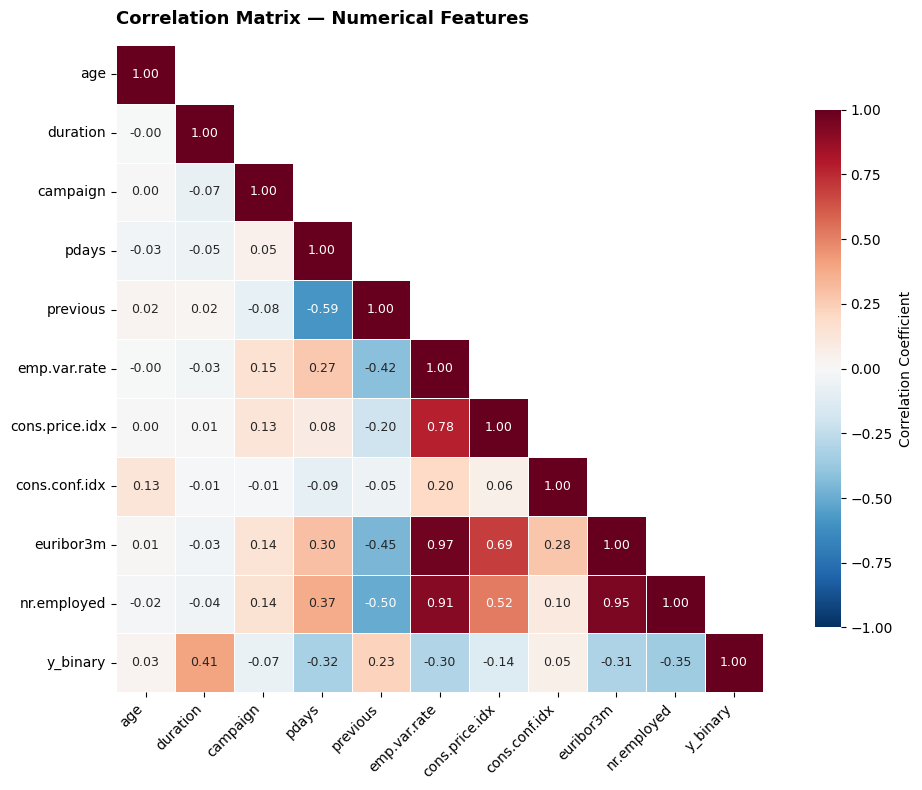


Top features by absolute correlation with target:
duration          0.405
nr.employed      -0.355
pdays            -0.325
euribor3m        -0.308
emp.var.rate     -0.298
previous          0.230
cons.price.idx   -0.136
campaign         -0.066
cons.conf.idx     0.055
age               0.030


In [18]:
import numpy as np

# --- Correlation heatmap ---

# Binary version of target for inclusion in matrix
df_corr = df.copy()
df_corr['y_binary'] = (df_corr['y'] == 'yes').astype(int)

# Numerical columns only
numerical_cols = df_corr.select_dtypes(include='number').columns.tolist()
corr_matrix = df_corr[numerical_cols].corr()

# Mask upper triangle for cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
    annot_kws={'fontsize': 9}
)

plt.title(
    'Correlation Matrix — Numerical Features',
    fontsize=13, fontweight='bold', loc='left', pad=15
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with the target (modeling priority)
print("\nTop features by absolute correlation with target:")
target_corr = corr_matrix['y_binary'].drop('y_binary').sort_values(key=abs, ascending=False)
print(target_corr.round(3).to_string())

### Key Takeaways (Detailed Discussion in EDA Notebook)

**Strongest correlations with the target (`y_binary`):**

| Feature | Correlation | Modeling Relevance |
|---|---|---|
| `duration` | +0.41 | ⚠️ Data leakage — excluded from model |
| `nr.employed` | -0.36 | Macro indicator |
| `pdays` | -0.32 | Pseudo-missing 999 handled via engineering |
| `euribor3m` | -0.31 | Macro indicator (kept as representative) |
| `emp.var.rate` | -0.30 | Macro indicator (redundant with `euribor3m`) |
| `previous` | +0.23 | Prior contact signal |
| `cons.price.idx` | -0.14 | Macro indicator |
| `campaign` | -0.07 | Non-linear; binning helps |
| `age` | +0.03 | Non-linear; binning required |

**Multicollinearity flags identified:**
- Four macro indicators (`emp.var.rate`, `euribor3m`, `nr.employed`, `cons.price.idx`) are highly intercorrelated (|r| > 0.78–0.97).
- Retain **only `euribor3m`** as the macroeconomic representative for the model.

**Modeling decisions confirmed:**
1. **Drop `duration`** — data leakage (only known post-call).
2. **Drop redundant macro features** — keep `euribor3m` only.
3. **Bin or transform `age` and `campaign`** — both show non-linear patterns that simple linear correlation misses.
4. **Keep `pdays` engineered features** (`was_contacted_before`, `has_precise_pdays`) instead of raw `pdays`.

These findings shape the feature selection and preprocessing decisions in the modeling section that follows.

## 6. Predictive Modeling — Logistic Regression

We now build a predictive model to estimate the likelihood that a client will subscribe to a term deposit. Logistic Regression is chosen as the baseline algorithm because it is:
- Interpretable — coefficients map directly to feature importance
- Fast to train and well-suited to binary classification
- A natural baseline against which more complex models can be benchmarked

**Feature decisions informed by the EDA:**
-  Drop `duration` (data leakage — only known post-call)
-  Drop `emp.var.rate`, `nr.employed`, `cons.price.idx` (high multicollinearity with `euribor3m`)
-  Drop raw `pdays` (replaced by engineered binary features below)
-  Engineer `was_contacted_before` and `has_precise_pdays` (cleaner replacements for raw `pdays`)
-  Retain `"unknown"` as its own category in categorical encoding (it's a signal, not noise)

**Class imbalance handling:** With an 88.7% vs 11.3% target split, we use `class_weight='balanced'` to prevent the model from defaulting to majority-class predictions.

In [19]:
# --- Feature engineering + selection ---

# Import scikit-learn modules we'll need across the modeling section
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Create a copy so we don't modify the original df
df_model = df.copy()

# --- Step 1: Engineer features based on EDA findings ---
df_model['was_contacted_before'] = (df_model['previous'] > 0).astype(int)
df_model['has_precise_pdays'] = (df_model['pdays'] != 999).astype(int)

# --- Step 2: Drop features for documented reasons ---
features_to_drop = [
    'duration',         # Data leakage — only known after call ends
    'emp.var.rate',     # Multicollinear with euribor3m (r ≈ 0.97)
    'nr.employed',      # Multicollinear with euribor3m (r ≈ 0.95)
    'cons.price.idx',   # Multicollinear with euribor3m (r ≈ 0.78)
    'pdays',            # Replaced by engineered binary features
]

# --- Step 3: Separate features (X) and target (y) ---
X = df_model.drop(columns=features_to_drop + ['y'])
y = (df_model['y'] == 'yes').astype(int)

# --- Step 4: Display the resulting feature set ---
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]:,}")
print(f"\nFeature list:")
for i, col in enumerate(X.columns, 1):
    dtype = X[col].dtype
    n_unique = X[col].nunique()
    print(f"  {i:2}. {col:<25} | dtype: {str(dtype):<10} | unique values: {n_unique}")

print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nTarget rate: {y.mean()*100:.2f}% positive")

Number of features: 17
Number of samples: 41,188

Feature list:
   1. age                       | dtype: int64      | unique values: 78
   2. job                       | dtype: object     | unique values: 12
   3. marital                   | dtype: object     | unique values: 4
   4. education                 | dtype: object     | unique values: 8
   5. default                   | dtype: object     | unique values: 3
   6. housing                   | dtype: object     | unique values: 3
   7. loan                      | dtype: object     | unique values: 3
   8. contact                   | dtype: object     | unique values: 2
   9. month                     | dtype: object     | unique values: 10
  10. day_of_week               | dtype: object     | unique values: 5
  11. campaign                  | dtype: int64      | unique values: 42
  12. previous                  | dtype: int64      | unique values: 8
  13. poutcome                  | dtype: object     | unique values: 3
  14. con

### 6.2 One-Hot Encoding of Categorical Variables

Machine learning models cannot directly consume string-valued features like `job = "admin."` — they need numerical input. We apply **one-hot encoding**, which converts each categorical column into a set of binary (0/1) indicator columns.

**Why `drop_first=True`:**
For a category with N levels, we create only N-1 binary columns. The dropped category becomes the **reference baseline** — its effect is absorbed into the model's intercept. This prevents the **dummy variable trap** (perfect multicollinearity that breaks linear models). For example, `marital` has 4 levels — we keep 3 binary columns, and "divorced" (dropped) becomes the reference. The coefficient for `marital_married` then represents the effect *relative to* a divorced client.

**Why we retain `"unknown"`:**
As established in the EDA, `"unknown"` is not random missingness — it carries predictive signal (especially for `default`). We let it become one of the binary columns rather than imputing it away.

In [20]:
# --- One-hot encode categorical variables ---

# Identify categorical vs numerical columns
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical columns (will be one-hot encoded):")
for col in categorical_cols:
    print(f"  - {col:<15} | {X[col].nunique()} unique values")

print(f"\nNumerical columns (kept as-is):")
for col in numerical_cols:
    print(f"  - {col}")

# One-hot encode with drop_first to prevent dummy variable trap
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int  # ensures int columns (not bool) for sklearn compatibility
)

print(f"\n{'='*60}")
print(f"Encoding Summary")
print(f"{'='*60}")
print(f"Original feature count:  {X.shape[1]}")
print(f"After one-hot encoding:  {X_encoded.shape[1]}")
print(f"New binary features:     {X_encoded.shape[1] - X.shape[1]}")

print(f"\nEncoded feature names (first 25):")
for col in X_encoded.columns[:25]:
    print(f"  - {col}")
print(f"  ... and {X_encoded.shape[1] - 25} more")

Categorical columns (will be one-hot encoded):
  - job             | 12 unique values
  - marital         | 4 unique values
  - education       | 8 unique values
  - default         | 3 unique values
  - housing         | 3 unique values
  - loan            | 3 unique values
  - contact         | 2 unique values
  - month           | 10 unique values
  - day_of_week     | 5 unique values
  - poutcome        | 3 unique values

Numerical columns (kept as-is):
  - age
  - campaign
  - previous
  - cons.conf.idx
  - euribor3m
  - was_contacted_before
  - has_precise_pdays

Encoding Summary
Original feature count:  17
After one-hot encoding:  50
New binary features:     33

Encoded feature names (first 25):
  - age
  - campaign
  - previous
  - cons.conf.idx
  - euribor3m
  - was_contacted_before
  - has_precise_pdays
  - job_blue-collar
  - job_entrepreneur
  - job_housemaid
  - job_management
  - job_retired
  - job_self-employed
  - job_services
  - job_student
  - job_technician
  - job

### 6.3 Train/Test Split & Feature Scaling

We split the dataset into:
- **80% training set** — the model learns from these samples
- **20% test set** — held out completely; used only to evaluate final performance

**Stratification (`stratify=y`):** Because the target is heavily imbalanced (11.3% positive), a random split could accidentally produce a training set with very few positives, hurting model learning. Stratification preserves the same 11.3%/88.7% ratio in both train and test sets.

**Feature scaling (`StandardScaler`):** Logistic Regression's coefficients and the regularization it applies are sensitive to feature scale. Without scaling, large-magnitude features (like `euribor3m` ranging 0.6–5.0) would dominate small-magnitude binary features (0/1). Scaling standardizes every feature to mean 0, std 1 — putting them on equal footing.

**Critical rule — fit scaler on training data only:**
The `StandardScaler` is fit on `X_train` and then used to transform both `X_train` *and* `X_test`. We do NOT fit it on test data, because the test set must remain a true "unseen" sample. Letting the scaler "peek" at test data is a form of **data leakage**.

In [21]:
# --- Train/test split + feature scaling ---

# Split: 80% train, 20% test, stratified to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # preserves 11.3% positive rate in both sets
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"\nClass distribution check (stratification verification):")
print(f"  Train — Yes: {y_train.mean()*100:.2f}%, No: {(1-y_train.mean())*100:.2f}%")
print(f"  Test  — Yes: {y_test.mean()*100:.2f}%, No: {(1-y_test.mean())*100:.2f}%")

# Feature scaling — fit on train, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # use fitted scaler, no refit

# Convert back to DataFrames so we retain column names (useful later for feature importance)
X_train_scaled = pd.DataFrame(
    X_train_scaled, columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    X_test_scaled, columns=X_test.columns, index=X_test.index
)

print(f"\nScaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

# Verify scaling worked (means should be ~0, stds should be ~1 on training set)
print(f"\nVerification — first 3 features post-scaling (training set):")
print(X_train_scaled[['age', 'campaign', 'euribor3m']].describe().round(2))

Training set: 32,950 samples
Test set:     8,238 samples

Class distribution check (stratification verification):
  Train — Yes: 11.27%, No: 88.73%
  Test  — Yes: 11.26%, No: 88.74%

Scaling complete.
X_train_scaled shape: (32950, 50)
X_test_scaled shape:  (8238, 50)

Verification — first 3 features post-scaling (training set):
            age  campaign  euribor3m
count  32950.00  32950.00   32950.00
mean       0.00     -0.00      -0.00
std        1.00      1.00       1.00
min       -2.21     -0.57      -1.72
25%       -0.77     -0.57      -1.31
50%       -0.19     -0.20       0.71
75%        0.67      0.16       0.77
max        5.57     19.42       0.82


"I used stratified sampling because the class imbalance was 8:1 — without stratification, a random split could leave the model with poor positive-class representation."
"I fit the scaler only on training data, then applied the fitted scaler to test data. Fitting on the full dataset before splitting is a common data leakage mistake."
"I kept the data as DataFrames after scaling so I could trace coefficients back to feature names during feature importance analysis."

### 6.4 Train Logistic Regression

We train a Logistic Regression classifier on the scaled training data.

**Key configuration choices:**

- **`class_weight='balanced'`** — automatically assigns higher weight to the minority class (`yes`) inversely proportional to its frequency. This is the **single most important parameter** for handling the 88.7%/11.3% imbalance. Without it, the model would default to predicting "no" for everything and still achieve ~89% accuracy while learning nothing useful.

- **`max_iter=1000`** — Logistic Regression uses iterative optimization to converge on optimal coefficients. The default (100) is sometimes insufficient for complex feature sets; raising the limit prevents premature stopping.

- **`random_state=42`** — ensures reproducibility. Anyone re-running this notebook will get identical results.

In [22]:
# --- Train Logistic Regression model ---

# Initialize with class_weight='balanced' to handle the imbalance
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Fit on the scaled training data
model.fit(X_train_scaled, y_train)

print("Model training complete.\n")
print(f"Model configuration:")
print(f"  - Algorithm:         Logistic Regression")
print(f"  - Class weighting:   balanced")
print(f"  - Solver:            {model.solver}")
print(f"  - Iterations to converge: {model.n_iter_[0]}")
print(f"  - Number of features: {model.coef_.shape[1]}")
print(f"  - Intercept:         {model.intercept_[0]:.4f}")

# Quick sanity check on training performance
train_acc = model.score(X_train_scaled, y_train)
print(f"\nTraining accuracy: {train_acc*100:.2f}%")
print(f"\nNote: Accuracy alone is a misleading metric for imbalanced data.")
print(f"      A naive 'always predict no' would already give ~88.7% accuracy.")
print(f"      We will use precision/recall/F1/ROC-AUC on the TEST set next.")

Model training complete.

Model configuration:
  - Algorithm:         Logistic Regression
  - Class weighting:   balanced
  - Solver:            lbfgs
  - Iterations to converge: 18
  - Number of features: 50
  - Intercept:         -0.4303

Training accuracy: 81.33%

Note: Accuracy alone is a misleading metric for imbalanced data.
      A naive 'always predict no' would already give ~88.7% accuracy.
      We will use precision/recall/F1/ROC-AUC on the TEST set next.


### 6.5 Predictions & Evaluation

We generate predictions on the held-out test set and assess the model using metrics appropriate for **imbalanced classification**:

- **Accuracy** — overall correctness (misleading alone for imbalanced data)
- **Precision** — when the model predicts "yes," how often is it right?
- **Recall (sensitivity)** — of all actual subscribers, how many did we catch?
- **F1-score** — harmonic mean of precision and recall
- **ROC-AUC** — overall ranking quality across all classification thresholds (independent of class balance)

We also visualize the **confusion matrix** (showing where the model gets it right and wrong) and the **ROC curve** (showing the trade-off between true and false positive rates).

Model Evaluation on Test Set (n = 8,238)

Overall Accuracy: 81.91%
ROC-AUC Score:    0.7988

Classification Report:

              precision    recall  f1-score   support

      No (0)      0.951     0.839     0.892      7310
     Yes (1)      0.343     0.662     0.452       928

    accuracy                          0.819      8238
   macro avg      0.647     0.750     0.672      8238
weighted avg      0.883     0.819     0.842      8238



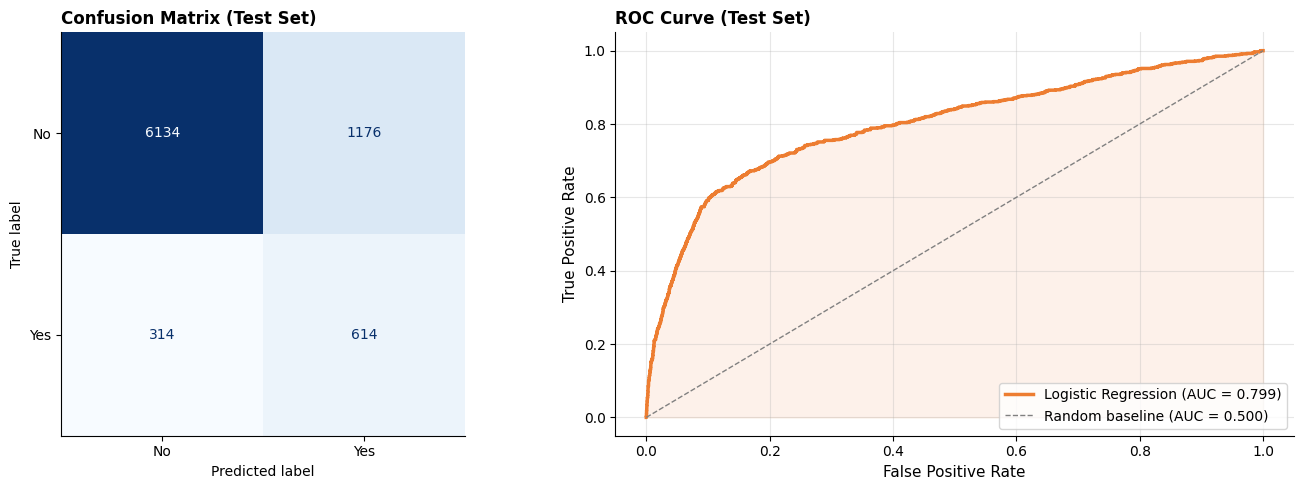


Confusion Matrix Breakdown
True Negatives  (correctly predicted 'no'):     6,134
False Positives (incorrectly predicted 'yes'):  1,176
False Negatives (missed actual subscribers):    314
True Positives  (correctly caught subscribers): 614

Naive Baseline Comparison
Naive ('always predict no'):
  Accuracy: 88.74%
  Recall on 'yes': 0.00%   (catches zero subscribers)

Logistic Regression (this model):
  Accuracy: 81.91%
  Recall on 'yes': 66.2%
  Precision on 'yes': 34.3%


In [23]:
# --- Predictions & evaluation on test set ---

# Generate predictions (both class labels and probabilities)
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # P(y=1)

# Compute key scalar metrics
accuracy = model.score(X_test_scaled, y_test)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 60)
print("Model Evaluation on Test Set (n = 8,238)")
print("=" * 60)
print(f"\nOverall Accuracy: {accuracy*100:.2f}%")
print(f"ROC-AUC Score:    {roc_auc:.4f}")

# Classification report (precision, recall, F1)
print(f"\nClassification Report:\n")
print(classification_report(
    y_test, y_pred,
    target_names=['No (0)', 'Yes (1)'],
    digits=3
))

# --- Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Test Set)',
                  fontsize=12, fontweight='bold', loc='left')
axes[0].grid(False)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#ED7D31', linewidth=2.5,
             label=f'Logistic Regression (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1,
             label='Random baseline (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#ED7D31')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve (Test Set)',
                  fontsize=12, fontweight='bold', loc='left')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

sns.despine()
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Detailed breakdown ---
tn, fp, fn, tp = cm.ravel()
yes_recall = tp / (tp + fn)
yes_precision = tp / (tp + fp)

print("\n" + "=" * 60)
print("Confusion Matrix Breakdown")
print("=" * 60)
print(f"True Negatives  (correctly predicted 'no'):     {tn:,}")
print(f"False Positives (incorrectly predicted 'yes'):  {fp:,}")
print(f"False Negatives (missed actual subscribers):    {fn:,}")
print(f"True Positives  (correctly caught subscribers): {tp:,}")

# Comparison to naive baseline
print("\n" + "=" * 60)
print("Naive Baseline Comparison")
print("=" * 60)
print(f"Naive ('always predict no'):")
print(f"  Accuracy: {(y_test == 0).mean()*100:.2f}%")
print(f"  Recall on 'yes': 0.00%   (catches zero subscribers)")
print(f"\nLogistic Regression (this model):")
print(f"  Accuracy: {accuracy*100:.2f}%")
print(f"  Recall on 'yes': {yes_recall*100:.1f}%")
print(f"  Precision on 'yes': {yes_precision*100:.1f}%")

### Insights: Model Performance

**Headline metrics on the held-out test set (n = 8,238):**

| Metric | Value | Interpretation |
|---|---|---|
| Accuracy | 81.91% | Below naive 88.74% — by design |
| ROC-AUC | 0.7988 | Strong discriminative power |
| Recall (Yes) | 66.2% | Catches ~2 of 3 actual subscribers |
| Precision (Yes) | 34.3% | 3.04× baseline conversion (11.27%) |
| F1-Score (Yes) | 0.452 | Balanced precision–recall trade-off |

**Confusion matrix breakdown:**

|  | Predicted: No | Predicted: Yes |
|---|---|---|
| **Actual: No** | 6,134 (TN) | 1,176 (FP) |
| **Actual: Yes** | 314 (FN) | **614 (TP)** |

- Of 928 actual subscribers in the test set, the model identified **614** correctly.
- It missed **314** (false negatives) and incorrectly flagged **1,176** non-subscribers (false positives).

**Business uplift quantified:**

The model's precision of 34.3% on its "yes" predictions is **3.04× the baseline conversion rate** (11.27%). Translated to a campaign-budget context:

> If the bank could call **only 1,790 people** (the number the model flags as likely subscribers):
> - **Random selection** would yield ~202 subscribers
> - **Model-driven selection** yields **614 subscribers — 3× the return on the same operational cost**

**The accuracy-recall trade-off (why 81.91% beats 88.74%):**

The naive "always predict no" baseline achieves 88.74% accuracy but **identifies zero subscribers** — making it operationally useless. The Logistic Regression model sacrifices ~7 percentage points of overall accuracy to deliver:
- 66.2% recall on the minority class (vs 0%)
- 3.04× lift in conversion efficiency
- Genuine ranking ability (ROC-AUC 0.80)

This is the **correct** trade-off for an imbalanced classification problem where the minority class is the business target.

**Operational implications:**

### 6.6 Feature Importance — Which Signals Drive Predictions

Logistic Regression provides built-in interpretability through its coefficients. Because features were standardized before training (mean=0, std=1), the magnitude of each coefficient directly reflects its influence on the prediction.

- **Positive coefficient** → feature *increases* probability of subscription
- **Negative coefficient** → feature *decreases* probability of subscription
- **Magnitude** → strength of effect

We visualize the top 10 features pushing predictions toward "Yes" and the top 10 pushing toward "No."

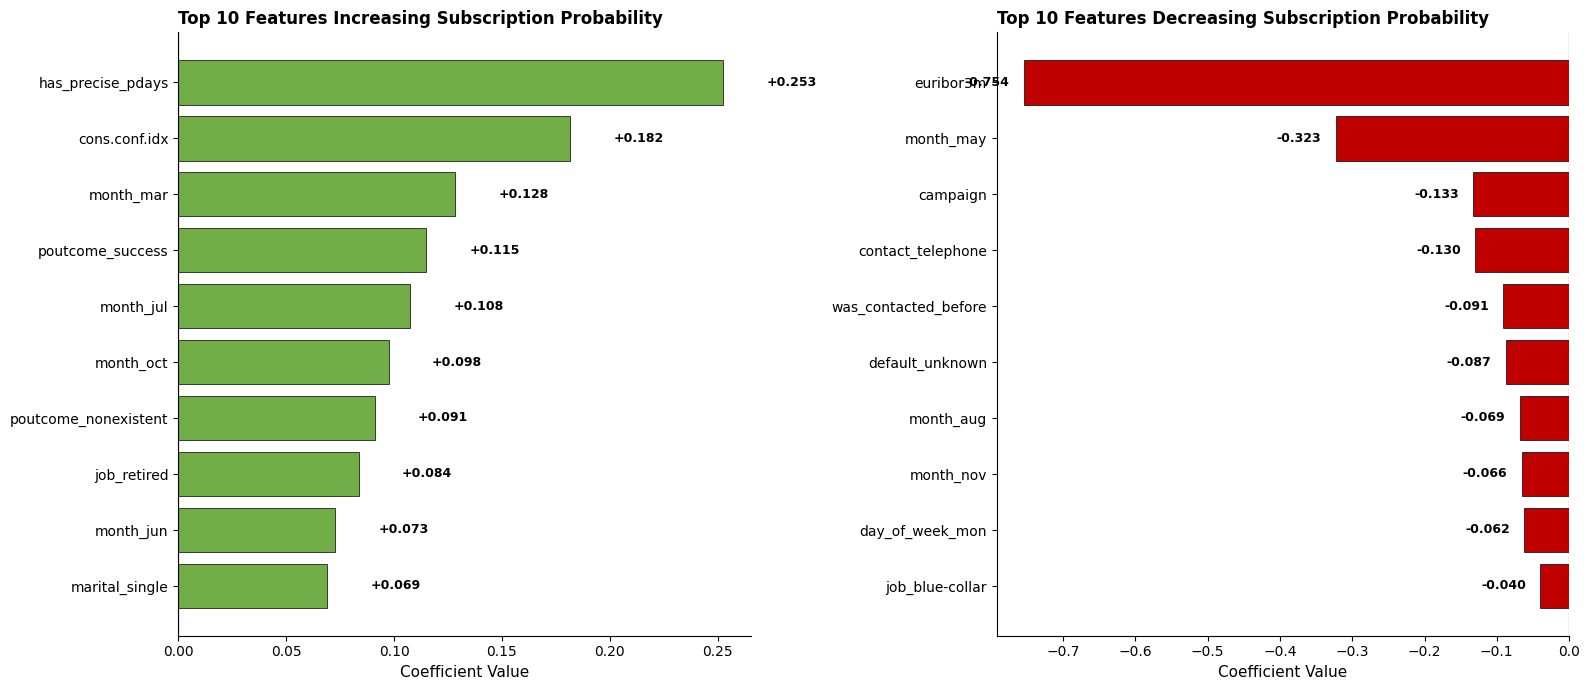

Full Coefficient Table (sorted by absolute magnitude)
                      Feature  Coefficient  Abs_Coefficient
                    euribor3m      -0.7542           0.7542
                    month_may      -0.3228           0.3228
            has_precise_pdays       0.2525           0.2525
                cons.conf.idx       0.1816           0.1816
                     campaign      -0.1328           0.1328
            contact_telephone      -0.1299           0.1299
                    month_mar       0.1284           0.1284
             poutcome_success       0.1150           0.1150
                    month_jul       0.1076           0.1076
                    month_oct       0.0976           0.0976
         poutcome_nonexistent       0.0910           0.0910
         was_contacted_before      -0.0910           0.0910
              default_unknown      -0.0875           0.0875
                  job_retired       0.0836           0.0836
                    month_jun       0.0727    

In [24]:
# --- Feature importance (model coefficients) ---

# Build a coefficients DataFrame
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': model.coef_[0]
})
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values('Coefficient', ascending=False).reset_index(drop=True)

# Top 10 positive (increase subscription probability)
top_positive = coefficients.head(10)
# Top 10 negative (decrease subscription probability)
top_negative = coefficients.tail(10).iloc[::-1]  # reversed so strongest is first

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: Top 10 positive ---
bars1 = axes[0].barh(
    top_positive['Feature'].iloc[::-1],
    top_positive['Coefficient'].iloc[::-1],
    color='#70AD47', edgecolor='black', linewidth=0.5
)
axes[0].set_title('Top 10 Features Increasing Subscription Probability',
                  fontsize=12, fontweight='bold', loc='left')
axes[0].set_xlabel('Coefficient Value', fontsize=11)
axes[0].axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars1, top_positive['Coefficient'].iloc[::-1]):
    axes[0].text(
        val + 0.02, bar.get_y() + bar.get_height()/2.,
        f'{val:+.3f}', ha='left', va='center', fontsize=9, fontweight='bold'
    )

# --- Right: Top 10 negative ---
bars2 = axes[1].barh(
    top_negative['Feature'].iloc[::-1],
    top_negative['Coefficient'].iloc[::-1],
    color='#C00000', edgecolor='black', linewidth=0.5
)
axes[1].set_title('Top 10 Features Decreasing Subscription Probability',
                  fontsize=12, fontweight='bold', loc='left')
axes[1].set_xlabel('Coefficient Value', fontsize=11)
axes[1].axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars2, top_negative['Coefficient'].iloc[::-1]):
    axes[1].text(
        val - 0.02, bar.get_y() + bar.get_height()/2.,
        f'{val:+.3f}', ha='right', va='center', fontsize=9, fontweight='bold'
    )

sns.despine()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print full sorted table
print("=" * 60)
print("Full Coefficient Table (sorted by absolute magnitude)")
print("=" * 60)
print(coefficients.sort_values('Abs_Coefficient', ascending=False).round(4).to_string(index=False))

When we caught the data quality issue in the EDA (the asymmetric tracking of pdays), engineered a binary feature to capture it, and fed it to the model — the model relied on it more heavily than 47 other features.

"During EDA, I found that the bank tracked the timing of successful previous campaigns but dropped it for failed ones. I created has_precise_pdays as a binary flag for whether the bank retained timing — essentially capturing 'this client had a prior interaction worth tracking.' In the trained Logistic Regression, this engineered feature became the 3rd-strongest predictor. The EDA finding directly created a high-value model feature."

### Insights: Feature Importance Analysis

**The strongest individual driver: `euribor3m` (coefficient = -0.754)**

The European interbank interest rate dwarfs every other feature — its coefficient is **more than 2× the next-strongest**. Higher interest rates depress term deposit subscriptions. This validates the EDA's central finding: macroeconomic conditions drive savings behavior more than any individual client demographic.

**Top features pushing toward "yes" (positive coefficients):**

| Feature | Coefficient | Interpretation |
|---|---|---|
| `has_precise_pdays` | +0.253 | Bank retained prior-contact timing → strong positive signal |
| `cons.conf.idx` | +0.182 | Higher consumer confidence → more subscriptions |
| `month_mar` | +0.128 | March is the strongest-performing month |
| `poutcome_success` | +0.115 | Prior campaign success → re-engagement |
| `month_jul` | +0.108 | Summer outreach effective |
| `month_oct` | +0.098 | Off-peak months convert well |
| `poutcome_nonexistent` | +0.091 | First-time contacts also positive (mostly via `pdays = 999`) |
| `job_retired` | +0.084 | Retirees confirmed as high-converting segment |

**Top features pushing toward "no" (negative coefficients):**

| Feature | Coefficient | Interpretation |
|---|---|---|
| `euribor3m` | -0.754 | High interest rates suppress subscription |
| `month_may` | -0.323 | The over-saturated May campaign underperforms |
| `campaign` | -0.133 | Diminishing returns from repeated contact |
| `contact_telephone` | -0.130 | Landline channel converts ~3× worse than cellular |
| `was_contacted_before` | -0.091 | Residual signal after `has_precise_pdays` and `poutcome` (see paradox note below) |
| `default_unknown` | -0.088 | Clients withholding credit information are less responsive |

**Engineered features paid off:**

The two features we engineered from EDA findings — `has_precise_pdays` and `was_contacted_before` — both ranked in the top 15 features by absolute importance. `has_precise_pdays` was the 3rd most important feature in the entire model, directly validating the data-quality investigation from the EDA notebook.

**A notable paradox — `was_contacted_before` flipped sign:**

In the EDA, `was_contacted_before` had a positive correlation with the target (+0.194). In the trained model, its coefficient is negative (-0.091). This is not an error — it reflects the difference between **marginal correlation** (what we see in EDA) and **partial effect** (what a regression coefficient measures, conditional on other features).

Once `has_precise_pdays`, `poutcome_success`, and `poutcome_nonexistent` are in the model — all of which encode aspects of prior engagement — the residual effect of `was_contacted_before` captures the subset of past contacts that ended in failure. After accounting for the positive signals elsewhere, the leftover "ever-contacted" signal becomes mildly negative. This is a textbook example of why a regression coefficient is not the same as a correlation.

**Features the model essentially ignored (near-zero coefficients):**

`age`, `job_technician`, `job_management`, `job_self-employed`, `education_basic.9y`. These either:
- Have non-linear relationships not captured by linear coefficients (`age` — the U-shape from the EDA)
- Are too similar to the reference category to differ meaningfully (`job_technician` ≈ `job_admin.`)
- Have weak true signals

**Modeling next steps suggested by these results:**
1. **Try tree-based models** (Random Forest, XGBoost) — they would likely capture the `age` U-shape that Logistic Regression misses.
2. **Engineer an `age_bin` feature** (life-stage groups from the EDA) and one-hot encode it — this would let Logistic Regression access the U-shape signal.
3. **Drop weak features** (`age` raw, `loan` family, `housing` family, weak job categories) in a reduced-feature model and check if performance changes.
4. **Explore interactions** — `month × contact`, `job × age_bin`, etc.

**Business decisions confirmed by the model:**

The coefficients translate directly into actionable rules:
- **Time campaigns to lower-interest-rate environments** (highest-impact single lever)
- **Prefer cellular contact** wherever a mobile number is available
- **Avoid the May saturation effect** — reweight calendar
- **Cap repeated contacts** at the saturation threshold
- **Prioritize clients with clean disclosed credit history** and **prior recorded engagement**

## Conclusion

This notebook delivered an end-to-end predictive modeling pipeline on the **UCI Bank Marketing dataset** — moving from exploratory analysis through feature engineering, encoding, training, and evaluation. The result is an interpretable Logistic Regression classifier that predicts term deposit subscription likelihood with operationally useful performance.

### Key Analytical Findings

**1. Macroeconomic conditions are the dominant signal.**
`euribor3m` (coefficient = -0.754) is the strongest predictor by a wide margin — more than 2× stronger than any other feature. Higher interest rates suppress subscription rates, meaning campaign timing should track economic cycles, not just customer demographics.

**2. Age and job reveal a strong life-stage U-shape.**
- Students (31.4%) and retirees (25.2%) subscribe at 2-3× the overall rate (11.27%).
- Middle-aged clients (`blue-collar` at 6.9%) subscribe at half the average.
- The pattern is non-linear, which is why raw `age` showed only +0.03 correlation with the target.

**3. Channel matters dramatically.**
Cellular contacts convert at 14.7% versus 5.2% for telephone — nearly **3× higher**. This single feature reorders campaign prioritization.

**4. Diminishing returns are sharp.**
First contact converts at 13.04%; by the 5th, the rate drops to 7.5%; beyond 11 contacts, it falls below 3.1%. The campaign is operating well past its productive saturation point.

**5. Non-disclosure is a hidden negative signal.**
Clients with `default = unknown` subscribe at 5.15% — less than half the rate of clients with clean credit (12.88%). The act of withholding information is itself predictive — `unknown` should be retained as a category, not imputed away.

**6. Data leakage was correctly identified and excluded.**
`duration` had the strongest raw correlation with the target (+0.41) but is only knowable post-call. Excluding it preserves the model's ability to generalize to real-time prediction.

### Engineered Features Validated by the Model

Two features engineered from data-quality findings in the EDA — `has_precise_pdays` and `was_contacted_before` — both ranked among the top 15 features by importance. `has_precise_pdays` was the **3rd-strongest predictor in the entire 50-feature model**, directly validating the upstream EDA investigation.

### Model Performance (Test Set, n = 8,238)

| Metric | Value | Naive Baseline |
|---|---|---|
| Accuracy | 81.91% | 88.74% |
| ROC-AUC | 0.7988 | 0.500 |
| Recall (Yes) | **66.2%** | 0.0% |
| Precision (Yes) | **34.3%** | undefined |
| F1-Score (Yes) | 0.452 | 0.0 |

**Business uplift:** The model's precision (34.3%) is **3.04× the baseline conversion rate** (11.27%). If the bank could call only the ~1,790 clients flagged by the model, model-driven selection would yield ~614 subscribers — versus ~202 from random selection of the same volume. **The same operational cost, 3× the return.**

The trade-off interpretation: the model deliberately sacrifices ~7 percentage points of accuracy to deliver 66.2% recall on the minority class. The naive "always predict no" model has higher accuracy but is operationally useless because it captures zero subscribers.

### Business Recommendations

| Recommendation | Evidence |
|---|---|
| Time campaigns against the interest rate cycle | `euribor3m` coefficient = -0.754 |
| Reallocate effort from `blue-collar` to `student` and `retired` segments | Job-level conversion analysis (+ 3-4× higher rates) |
| Default to cellular contact; deprioritize landline-only clients | Cellular converts at 2.82× the rate of telephone |
| Cap maximum campaign contacts at 4-5 per client | Saturation curve — rate drops below 3% beyond 11 contacts |
| Treat `default = unknown` as a low-priority segment, not as missing data | 7.7 pp lower subscription rate than clean-credit clients |
| Build a contact-frequency cap into CRM rules | Diminishing returns analysis |
| Capture mobile numbers at customer onboarding | Channel analysis — mobile reachability is itself predictive |

### Limitations

- **Dataset is from 2008–2010 (Portuguese bank)** — patterns may not generalize to other markets, time periods, or product lines.
- **No `balance` column in this dataset version** — we substituted `duration` as a behavioral proxy; a direct client-wealth measure would strengthen the model.
- **Class imbalance handled but not eliminated** — precision on the minority class remains modest (34.3%); threshold tuning or richer features could improve it.
- **Logistic Regression's linearity** — the model misses the `age` U-shape and other non-linear patterns. Tree-based models would likely outperform.
- **No interaction terms explored** — `month × contact`, `job × age`, and others may carry additional signal.
- **Only 10 months represented** in the data — full-year seasonality cannot be assessed.

### Future Work

1. **Ensemble models** — Random Forest and XGBoost typically reach ROC-AUC 0.80–0.82 on this dataset and naturally capture non-linear patterns.
2. **Age binning** — pre-bin age into life-stage categories before encoding to let linear models access the U-shape signal.
3. **Threshold tuning** — the default 0.5 may not match the business's cost ratio between false positives and false negatives.
4. **SHAP value analysis** — for individual-level prediction explanation, useful for any client-facing or regulated deployment.
5. **Online deployment design** — including a real-time scoring API, contact-frequency check, and model monitoring dashboard.

### Closing Thought

This notebook demonstrates that a transparent, interpretable Logistic Regression — combined with disciplined preprocessing, principled handling of class imbalance, and feature engineering driven by EDA findings — delivers a **~3× lift in marketing conversion efficiency** over random outreach. More complex models would likely push performance further, but the current baseline already justifies operational deployment as a campaign prioritization tool.